# SILVA Positive-Concave Equilibrium

This lab derives positive-concave order structure, trains the vector variant,
runs the convolutional variant, and checks state and weight positivity. The
mechanism follows pcDEQ [[76]](https://jseluis.github.io/silva-networks/paper/references/#ref-76).

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[1]](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [[4]](https://jseluis.github.io/silva-networks/paper/references/#ref-4), [[76]](https://jseluis.github.io/silva-networks/paper/references/#ref-76), [[81]](https://jseluis.github.io/silva-networks/paper/references/#ref-81). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import matplotlib.pyplot as plt
import torch

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
torch.manual_seed(91)

from silva_networks import (
    SILVAPositiveConcaveEquilibrium,
    SolverConfig,
    make_positive_concave_dataset,
)

## 1. Positive-Concave Map

$$
z^\star=\phi(W_+z^\star+s_+(x)),
\qquad W_+\geq0,
\qquad s_+(x)\geq0.
$$

SILVA supports a smooth positive parameterization

$$
W_+=\operatorname{softplus}(\widetilde W)+\epsilon_w.
$$

For source-repository alignment it also supports weight normalization,

$$
W_+=g_+\frac{v_+}{\lVert v_+\rVert}+\epsilon_w,
$$

where $v_+$ and $g_+$ are projected onto the nonnegative orthant after each
optimizer update. The direct projected parameterization is available as a
controlled ablation.

Variant 1 uses a strictly positive softplus source with tanh, softsign, or
ReLU6. Variant 2 uses a nonnegative ReLU source with sigmoid. Standard
fixed-point iteration retains the positive orthant.

In [3]:
data = make_positive_concave_dataset(samples=48, seed=92)
config = SolverConfig(
    solver="picard", max_iter=45, tol=1e-6, backward_mode="unrolled"
)
model = SILVAPositiveConcaveEquilibrium(
    3, 5, 1, variant=1, activation="tanh", config=config
)
initial = model(data.inputs, return_result=True)
assert initial.minimum_weight > 0
assert initial.state.min() >= 0
print("minimum recurrent weight:", float(initial.minimum_weight.detach()))
print("minimum state:", float(initial.state.min().detach()))
print("initial residual:", initial.solver_result.residual)

minimum recurrent weight: 0.006715358234941959
minimum state: 0.008567964658141136
initial residual: 2.265795160383277e-07


## 2. Compact Positive Regression

The known target is generated by a bounded nonnegative recurrent map. Training
checks the complete source-transition-readout gradient path rather than only a
standalone activation.

In [4]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
losses = []
for _ in range(45):
    optimizer.zero_grad()
    prediction = model(data.inputs)
    loss = torch.nn.functional.mse_loss(prediction, data.target)
    loss.backward()
    optimizer.step()
    losses.append(float(loss.detach()))

trained = model(data.inputs, return_result=True)
assert losses[-1] < losses[0]
assert trained.state.min() >= 0
print("initial/final loss:", losses[0], losses[-1])
print("trained residual:", trained.solver_result.residual)

initial/final loss: 0.17425553500652313 0.005625593010336161
trained residual: 1.673862897177969e-07


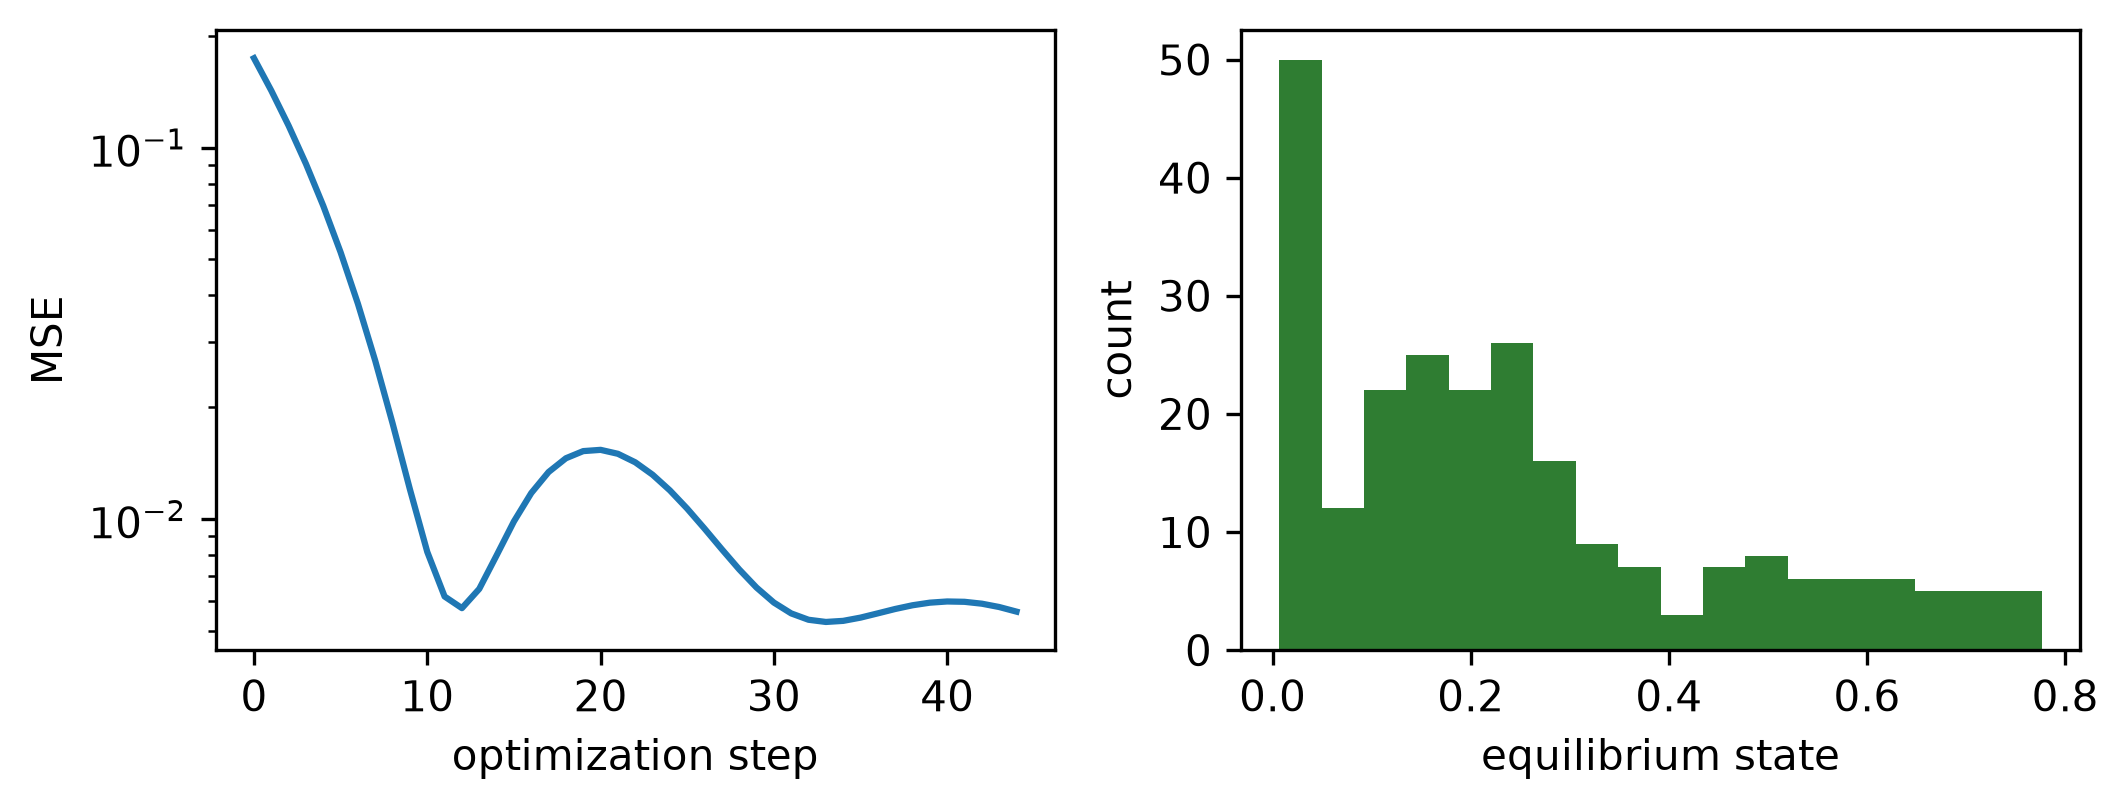

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(7.2, 2.8))
axes[0].semilogy(losses)
axes[0].set(xlabel="optimization step", ylabel="MSE")
axes[1].hist(trained.state.detach().flatten(), bins=18, color="#2f7d32")
axes[1].set(xlabel="equilibrium state", ylabel="count")
figure.tight_layout()
plt.show()

## 3. Spatial Positive-Concave Point

For a convolutional state,

$$
Z^\star=\phi(K_+*Z^\star+S_+(X)),
\qquad K_+\geq0.
$$

The state shape remains $(B,C,H,W)$, so this transition can sit inside a larger
image architecture without flattening the field.

In [6]:
spatial = SILVAPositiveConcaveEquilibrium(
    2,
    4,
    1,
    variant=2,
    operator="conv2d",
    kernel_size=3,
    config=SolverConfig(max_iter=8, tol=1e-5, backward_mode="unrolled"),
)
images = torch.rand(3, 2, 7, 9)
spatial_result = spatial(images, return_result=True)
assert spatial_result.output.shape == (3, 1, 7, 9)
assert torch.all((0 <= spatial_result.state) & (spatial_result.state <= 1))
print("spatial output:", spatial_result.output.shape)
print("spatial state range:", float(spatial_result.state.min()), float(spatial_result.state.max()))

spatial output: torch.Size([3, 1, 7, 9])
spatial state range: 0.5153920650482178 0.7998380661010742


## 4. Source-Aligned Weight Projection

The reference training loop applies weight normalization and clamps its
direction and magnitude parameters after every optimizer step. This cell uses
the same policy while retaining SILVA's solver and result object. The smooth
softplus mode above remains useful when a differentiable positivity
parameterization is preferred.

In [7]:
projected = SILVAPositiveConcaveEquilibrium(
    3,
    5,
    1,
    variant=1,
    activation="tanh",
    weight_parameterization="source_weight_norm",
    config=config,
)
projected_optimizer = torch.optim.Adam(projected.parameters(), lr=1e-2)
projected_optimizer.zero_grad()
projected_loss = torch.nn.functional.mse_loss(
    projected(data.inputs), data.target
)
projected_loss.backward()
projected_optimizer.step()
projected.project_nonnegative_()
projected_result = projected(data.inputs, return_result=True)
assert projected.transition.weight_scale is not None
assert projected.transition.raw_weight.min() >= 0
assert projected.transition.weight_scale.min() >= 0
assert projected_result.minimum_weight >= 0
print("projected loss:", float(projected_loss.detach()))
print("minimum direction:", float(projected.transition.raw_weight.min()))
print("minimum magnitude:", float(projected.transition.weight_scale.min()))

projected loss: 0.019430672749876976
minimum direction: 0.0
minimum magnitude: 0.0


## 5. Attributed Positive Image Check

CIFAR-10 pixels scaled to $[0,1]$ satisfy the input-side positivity required by
the convolutional branch [[81]](https://jseluis.github.io/silva-networks/paper/references/#ref-81). The experiment keeps the spatial state
$z^\star\in\mathbb{R}^{B\times C_z\times H\times W}$, averages only the final
class field, and projects the recurrent parameter after each optimizer step.
The small snapshot verifies the complete trainable path rather than benchmark
accuracy.

In [8]:
from urllib.request import urlretrieve
from silva_networks import load_source_snapshot

snapshot_path = root / "docs/assets/source-data/cifar10-balanced-10.pt"
if not snapshot_path.exists():
    snapshot_path = Path(".silva-source-data") / "cifar10-balanced-10.pt"
    snapshot_path.parent.mkdir(parents=True, exist_ok=True)
    snapshot_url = (
        "https://raw.githubusercontent.com/jseluis/silva-networks/main/"
        "docs/assets/source-data/cifar10-balanced-10.pt"
    )
    urlretrieve(snapshot_url, snapshot_path)

source_sample = load_source_snapshot(snapshot_path)
print("dataset:", source_sample.receipt.dataset)
print("source indices:", source_sample.receipt.selected_indices)
print("content SHA-256:", source_sample.receipt.content_sha256)
print("preprocessing:")
for step in source_sample.receipt.preprocessing:
    print(" -", step)

dataset: CIFAR10
source indices: (38683, 42292, 41716, 41053, 14490, 10657, 14443, 46034, 32019, 43901)
content SHA-256: 2c9f290825dc8690b27ca159d4681cda3db2198d35352f888bc3fbed23f21dfe
preprocessing:
 - deterministic class-balanced selection
 - scale image values to [0, 1]
 - bilinear resize to 16x16


In [9]:
from torch.nn import functional as F

real_images = source_sample.tensors["images"]
real_labels = source_sample.tensors["labels"].long()
real_model = SILVAPositiveConcaveEquilibrium(
    3,
    8,
    10,
    operator="conv2d",
    variant=1,
    weight_parameterization="projected",
    config=SolverConfig(
        solver="picard",
        max_iter=80,
        tol=1e-6,
        backward_mode="unrolled",
        anderson_batch_dims=1,
    ),
)
optimizer = torch.optim.Adam(real_model.parameters(), lr=3e-3)
real_losses = []
for _ in range(3):
    optimizer.zero_grad()
    real_result = real_model(real_images, return_result=True)
    logits = real_result.output.mean(dim=(-2, -1))
    real_loss = F.cross_entropy(logits, real_labels)
    real_loss.backward()
    optimizer.step()
    real_model.project_nonnegative_()
    real_losses.append(float(real_loss.detach()))

real_result = real_model(real_images, return_result=True)
print("loss trajectory:", real_losses)
print("minimum recurrent weight:", float(real_result.minimum_weight))
print("minimum equilibrium state:", float(real_result.state.min()))
assert real_result.minimum_weight >= 0
assert real_result.state.min() >= 0

loss trajectory: [2.390577793121338, 2.3847806453704834, 2.374962091445923]
minimum recurrent weight: 9.99999993922529e-09
minimum equilibrium state: 0.04371897503733635


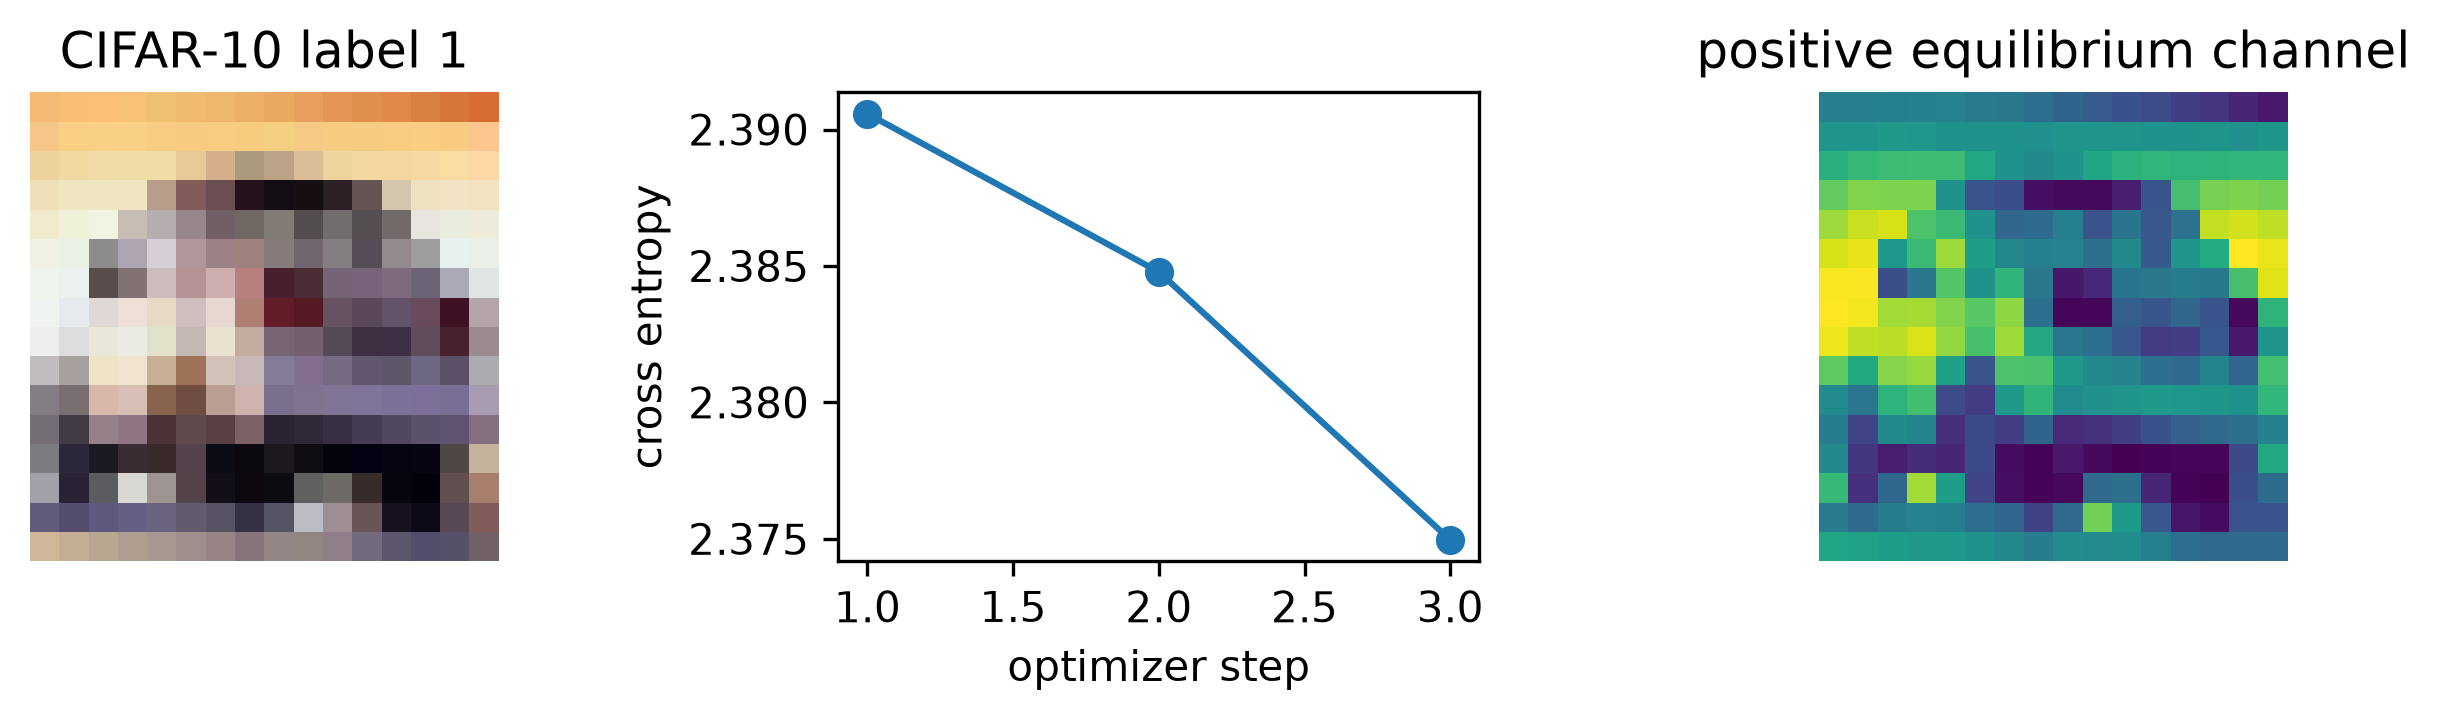

In [10]:
figure, axes = plt.subplots(1, 3, figsize=(8.4, 2.5))
axes[0].imshow(real_images[1].permute(1, 2, 0))
axes[0].set_title(f"CIFAR-10 label {int(real_labels[1])}")
axes[0].axis("off")
axes[1].plot(range(1, len(real_losses) + 1), real_losses, marker="o")
axes[1].set(xlabel="optimizer step", ylabel="cross entropy")
axes[2].imshow(real_result.state[1, 0].detach(), cmap="viridis")
axes[2].set_title("positive equilibrium channel")
axes[2].axis("off")
figure.tight_layout()
plt.show()

## Source-Scale Reproduction Contract

The compact run above verifies the defining mechanism, shapes, diagnostics,
and gradients. A published benchmark requires the source data, preprocessing,
architecture dimensions, optimization schedule, seeds, and evaluation budget.
The executable registry keeps those obligations beside the constructor.

In [11]:
from silva_networks import silva_reproduction_spec

spec = silva_reproduction_spec('silva_positive_concave_equilibrium')
print("equation:", spec.equation)
print("datasets:", spec.datasets)
print("data sources:")
for value in spec.data_sources:
    print(" -", value)
print("source-scale steps:")
for index, value in enumerate(spec.source_scale_steps, start=1):
    print(f" {index}. {value}")
print("metrics:", spec.metrics)
print("preserved mechanisms:", spec.preserved_mechanisms)
print("SILVA extension points:", spec.silva_extensions)
print("benchmark obligations:", spec.benchmark_requirements)
print("constructor:", spec.constructor_signature)

equation: z_star=phi(W_positive z_star+s_positive(x)); W_positive>=0
datasets: ('MNIST', 'CIFAR-10', 'SVHN', 'compact positive-concave vector and image equilibria')
data sources:
 - https://proceedings.mlr.press/v235/gabor24a.html
 - https://github.com/mateuszgabor/pcdeq
source-scale steps:
 1. Acquire one source vision task and reproduce its image preprocessing, split, and classifier head.
 2. Match published variant 1 or 2, nonnegative parameterization, activation, convolutional width, and fixed-point budget.
 3. Verify positivity and compact convergence first, then report task accuracy, residual, runtime, and memory with all source hyperparameters.
metrics: ('task accuracy', 'minimum state and weight', 'fixed-point residual', 'runtime and memory')
preserved mechanisms: ('entrywise nonnegative recurrent operators and nonnegative source injection', 'published variant-one tanh/softsign/ReLU6 and variant-two sigmoid maps', 'fixed-point iteration over vector or convolutional positive-con

## From 37 Silva Positive Concave Equilibrium to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the tensor solved to equilibrium |
| Condition | the observed input or source tensor |
| Repeated computation | the state-preserving transition evaluated by the root solver |
| Required invariants | shape, device, dtype, finiteness, and differentiability |
| Replaceable components | initializer, source encoder, transition, readout, and solver |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


### Replace the Positive Source, Transition, and Readout

```python
model = SILVAPositiveConcaveEquilibrium(
    in_dim=input_channels,
    state_dim=state_channels,
    out_dim=output_channels,
    variant=1,
    operator="conv2d",
    transition=my_positive_concave_transition,
    source=my_source,
    readout=my_readout,
    config=solver_config,
)
```

Every recurrent weight must remain nonnegative and the activation must remain
increasing and concave on the positive orthant. Explicit downsampling can link
several convolutional equilibrium points. Reproduce the source projection or
reparameterization policy, activation list, stopping rule, and image
preprocessing rather than assuming that any positive state is sufficient.


In [12]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**fixed-point residual and task error against a deterministic target**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **state width, batch size, and data volume**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [13]:
notebook_reproduction_record = {
    "notebook": '37_silva_positive_concave_equilibrium.ipynb',
    "state": 'the tensor solved to equilibrium',
    "condition": 'the observed input or source tensor',
    "transition": 'the state-preserving transition evaluated by the root solver',
    "invariants": 'shape, device, dtype, finiteness, and differentiability',
    "compact_metric": 'fixed-point residual and task error against a deterministic target',
    "scale_axis": 'state width, batch size, and data volume',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '37_silva_positive_concave_equilibrium.ipynb',
 'state': 'the tensor solved to equilibrium',
 'condition': 'the observed input or source tensor',
 'transition': 'the state-preserving transition evaluated by the root solver',
 'invariants': 'shape, device, dtype, finiteness, and differentiability',
 'compact_metric': 'fixed-point residual and task error against a deterministic target',
 'scale_axis': 'state width, batch size, and data volume'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **transition feedback factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **the tensor solved to equilibrium**, and its repeated map,
**the state-preserving transition evaluated by the root solver**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [14]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('transition feedback factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


transition feedback factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


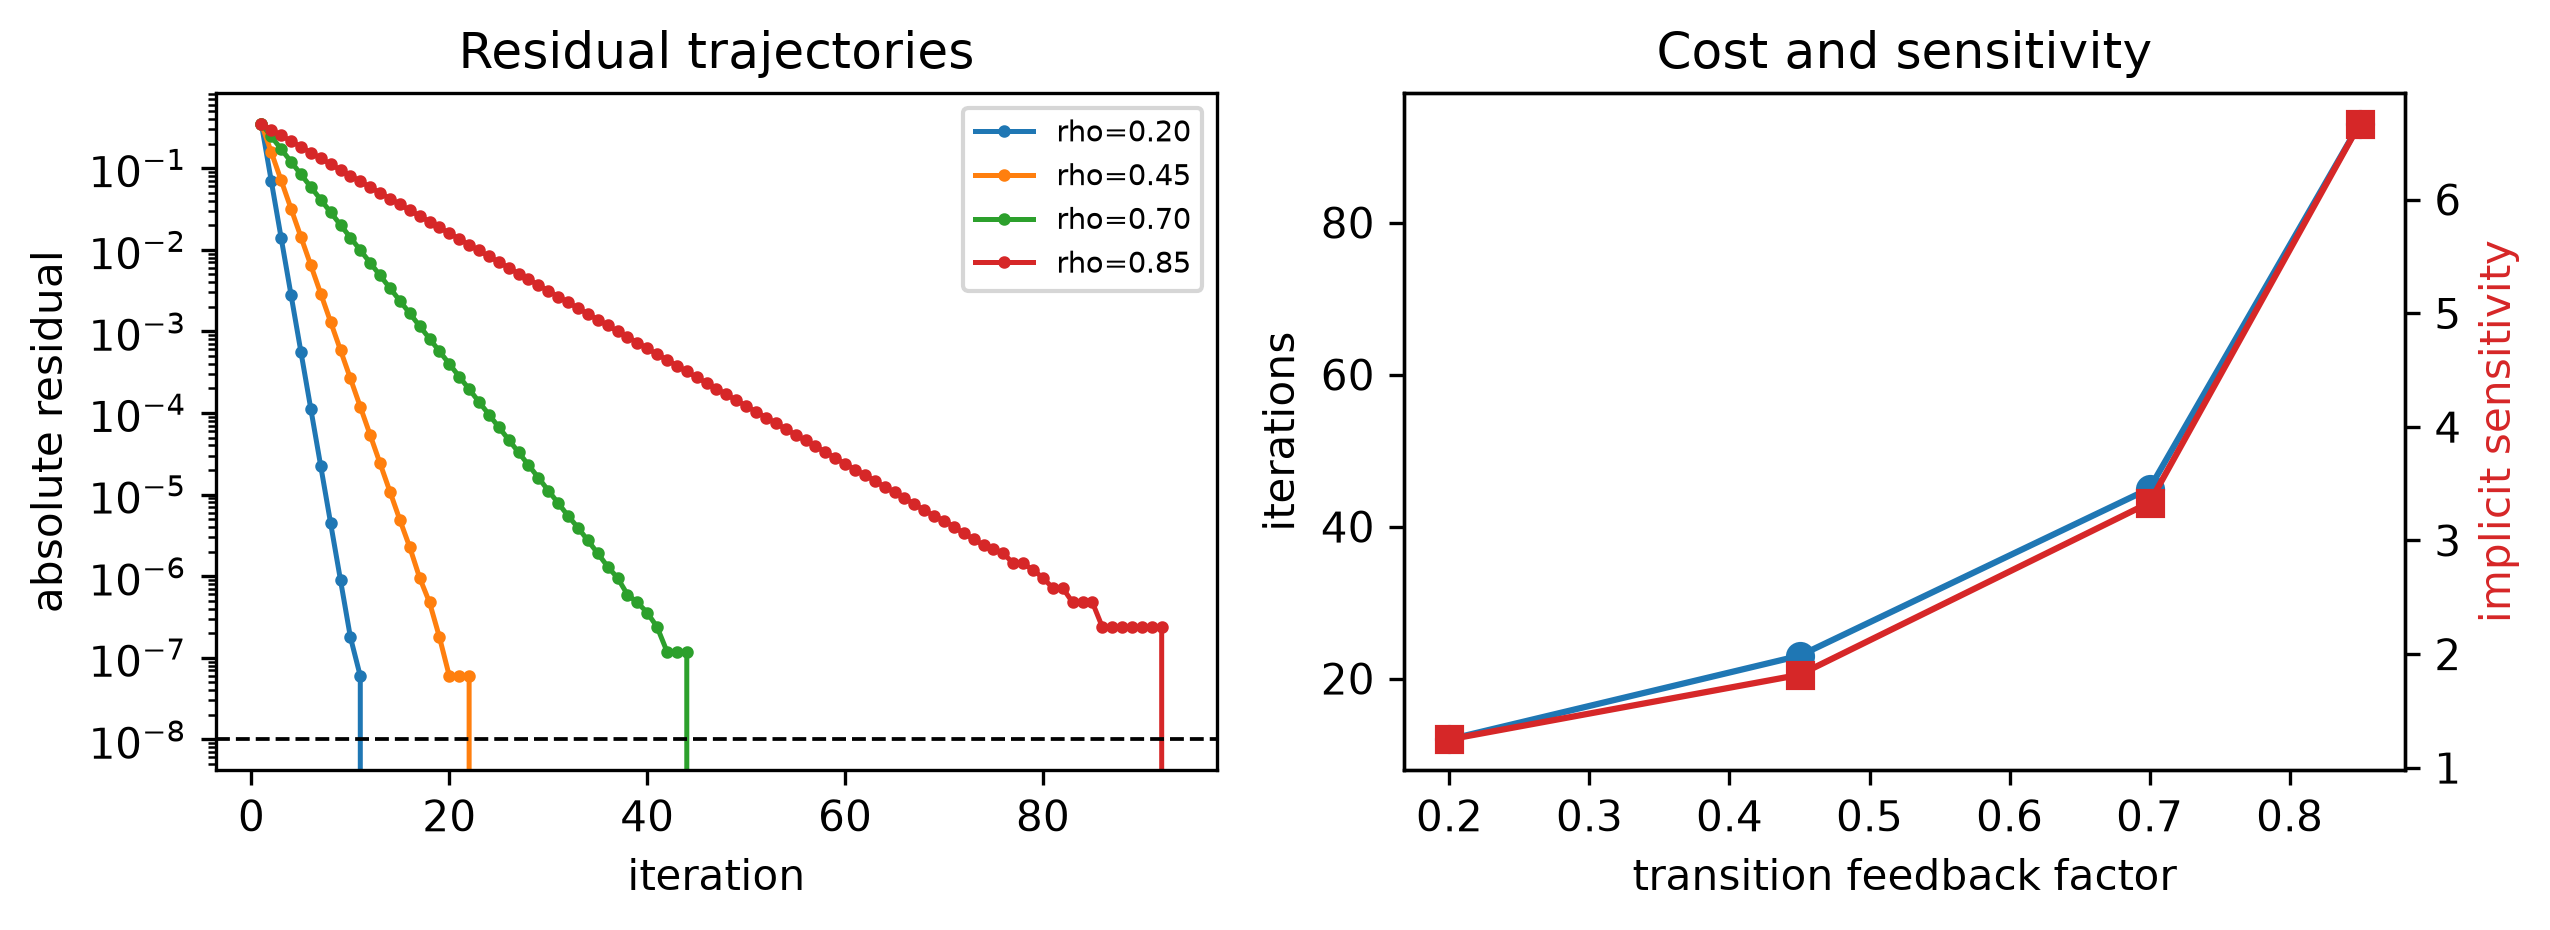

In [15]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('transition feedback factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the transition feedback factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | fixed-point residual and task error against a deterministic target |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | shape, device, dtype, finiteness, and differentiability |
| Scale sweep | Change one of state width, batch size, and data volume at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| Why do positivity and concavity guarantee the fixed point? | [Structured Equilibrium Families](https://jseluis.github.io/silva-networks/learn/structured-equilibrium-families/#positive-concave-equilibrium) |
| Which dense, convolutional, and replaceable parts are public? | [Structured Equilibria API](https://jseluis.github.io/silva-networks/api/structured_equilibria/) |
| How is the compact positive task constructed? | [Structured Data API](https://jseluis.github.io/silva-networks/api/structured_data/) |
